**项目实战-手把手搭建淋巴细胞检测网路**<br/>
医院A需要开发一个快速区分淋巴细胞和普通白细胞的系统并用于医疗诊断<br/>
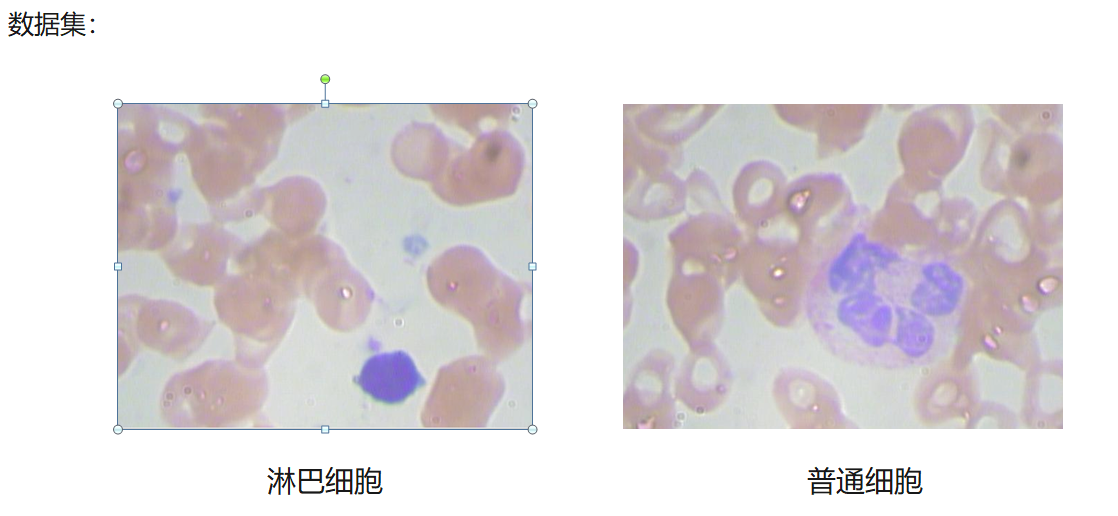

In [6]:
# 数据预处理

import os
import numpy as np
import cv2
import tensorflow as tf

# 训练数据路径（中文路径会存在问题，访问不到图片，这里统一采用相对路径）
# train_path = r"C:/Users/马铃薯/Python/爬虫/python-AI训练营-搭建淋巴细胞自动检测网络/Dataset/train/"
train_path = "Dataset/train/"
# 类别列表：LYMPHOCYTE-淋巴细胞  NEUTROPHIL-中性粒细胞
blood_class = ["LYMPHOCYTE","NEUTROPHIL"]
# 输入宽度
width = 128
# 输入高度
height = 128
# 通道数（RGB三通道）
channels = 3

# 获取训练数据的pathlist
def get_images(blood):
    # 读取图片全路径
    blood_dir = train_path+blood
    # 添加到路径列表中
    images = [blood+"/"+im for im in os.listdir(blood_dir)]
    return images

# 读取图片
def read_image(src):
    # opencv库,根据路径读取图片
    im = cv2.imread(src)
    # 根据输出尺寸resize图片尺寸
    im = cv2.resize(im, (width, height))

    return im

# 创建存储数据的列表
files = []
y_all = []

# 加载图片和label
for blood in blood_class:
    # 1.调用，获取训练数据的路径列表方法
    blood_files = get_images(blood)
    # print(blood_files)

    # 2.添加到总路径列表
    # extend()方法,将另外一个列表中所有的元素，逐个插入到指定列表中
    files.extend(blood_files)

    # 3.创建了一个长度位2的全0行的数组（用来区分LYMPHOCYTE-淋巴细胞和NEUTROPHIL-中性粒细胞）
    y_zero = np.zeros(len(blood_class))
    # 设置one-hot格式（相当于采用二进制的方法，LYMPHOCYTE-淋巴细胞-->10,NEUTROPHIL-中性粒细胞01）
    y_zero[blood_class.index(blood)] = 1
    # print(y_zero)

    # 4.将转化成one-hot格式的label数据，添加到y_all中
    y_list = [y_zero for i in blood_files]
    # print(y_list)
    y_all.extend(y_list)
    print("标签为{0}类型的图片有{1}张！".format(blood,len(blood_files)))

# keras 要求输入是array的形式，所以需要对list进行array处理
# 标签
y_all = np.array(y_all)
print("标签矩阵的维度：",y_all.shape)
# 图片数据（初始化）
X_all = np.ndarray((len(files), width, height, channels), dtype=np.float32)
print("图片矩阵的维度",X_all.shape)

# 将真实的图片数据（矩阵）加载进来
for index,im in enumerate(files):
    # 调用，读取图片方法
    # 需要注意的是，返回的图片矩阵要根据X_all的width和height，重新定义图片尺寸
    print("正在加载实际图片数据到X_all中,{0}/{1}...".format(index+1,len(X_all)))
    X_all[index] = read_image(train_path+im)
    # print(X_all)
print("实际图片数据加载成功，训练图像的矩阵维度为：{}".format(X_all.shape))

# 标准化数据集
# np.mean()，对矩阵所有元素求均值
# np.std()，计算矩阵标准差
def center_normalize(x):
    return (x - np.mean(x)) / np.std(x)

# 对训练集X_all进行标准化处理
X_all = center_normalize(X_all)
# print(X_all)

标签为LYMPHOCYTE类型的图片有2483张！
标签为NEUTROPHIL类型的图片有2499张！
标签矩阵的维度： (4982, 2)
图片矩阵的维度 (4982, 128, 128, 3)
正在加载实际图片数据到X_all中,1/4982...
正在加载实际图片数据到X_all中,2/4982...
正在加载实际图片数据到X_all中,3/4982...
正在加载实际图片数据到X_all中,4/4982...
正在加载实际图片数据到X_all中,5/4982...
正在加载实际图片数据到X_all中,6/4982...
正在加载实际图片数据到X_all中,7/4982...
正在加载实际图片数据到X_all中,8/4982...
正在加载实际图片数据到X_all中,9/4982...
正在加载实际图片数据到X_all中,10/4982...
正在加载实际图片数据到X_all中,11/4982...
正在加载实际图片数据到X_all中,12/4982...
正在加载实际图片数据到X_all中,13/4982...
正在加载实际图片数据到X_all中,14/4982...
正在加载实际图片数据到X_all中,15/4982...
正在加载实际图片数据到X_all中,16/4982...
正在加载实际图片数据到X_all中,17/4982...
正在加载实际图片数据到X_all中,18/4982...
正在加载实际图片数据到X_all中,19/4982...
正在加载实际图片数据到X_all中,20/4982...
正在加载实际图片数据到X_all中,21/4982...
正在加载实际图片数据到X_all中,22/4982...
正在加载实际图片数据到X_all中,23/4982...
正在加载实际图片数据到X_all中,24/4982...
正在加载实际图片数据到X_all中,25/4982...
正在加载实际图片数据到X_all中,26/4982...
正在加载实际图片数据到X_all中,27/4982...
正在加载实际图片数据到X_all中,28/4982...
正在加载实际图片数据到X_all中,29/4982...
正在加载实际图片数据到X_all中,30/4982...
正在加载实际图片数据到X_all中,31/4982...
正在加载实际图片数据到

正在加载实际图片数据到X_all中,344/4982...
正在加载实际图片数据到X_all中,345/4982...
正在加载实际图片数据到X_all中,346/4982...
正在加载实际图片数据到X_all中,347/4982...
正在加载实际图片数据到X_all中,348/4982...
正在加载实际图片数据到X_all中,349/4982...
正在加载实际图片数据到X_all中,350/4982...
正在加载实际图片数据到X_all中,351/4982...
正在加载实际图片数据到X_all中,352/4982...
正在加载实际图片数据到X_all中,353/4982...
正在加载实际图片数据到X_all中,354/4982...
正在加载实际图片数据到X_all中,355/4982...
正在加载实际图片数据到X_all中,356/4982...
正在加载实际图片数据到X_all中,357/4982...
正在加载实际图片数据到X_all中,358/4982...
正在加载实际图片数据到X_all中,359/4982...
正在加载实际图片数据到X_all中,360/4982...
正在加载实际图片数据到X_all中,361/4982...
正在加载实际图片数据到X_all中,362/4982...
正在加载实际图片数据到X_all中,363/4982...
正在加载实际图片数据到X_all中,364/4982...
正在加载实际图片数据到X_all中,365/4982...
正在加载实际图片数据到X_all中,366/4982...
正在加载实际图片数据到X_all中,367/4982...
正在加载实际图片数据到X_all中,368/4982...
正在加载实际图片数据到X_all中,369/4982...
正在加载实际图片数据到X_all中,370/4982...
正在加载实际图片数据到X_all中,371/4982...
正在加载实际图片数据到X_all中,372/4982...
正在加载实际图片数据到X_all中,373/4982...
正在加载实际图片数据到X_all中,374/4982...
正在加载实际图片数据到X_all中,375/4982...
正在加载实际图片数据到X_all中,376/4982...
正在加载实际图片数据

正在加载实际图片数据到X_all中,693/4982...
正在加载实际图片数据到X_all中,694/4982...
正在加载实际图片数据到X_all中,695/4982...
正在加载实际图片数据到X_all中,696/4982...
正在加载实际图片数据到X_all中,697/4982...
正在加载实际图片数据到X_all中,698/4982...
正在加载实际图片数据到X_all中,699/4982...
正在加载实际图片数据到X_all中,700/4982...
正在加载实际图片数据到X_all中,701/4982...
正在加载实际图片数据到X_all中,702/4982...
正在加载实际图片数据到X_all中,703/4982...
正在加载实际图片数据到X_all中,704/4982...
正在加载实际图片数据到X_all中,705/4982...
正在加载实际图片数据到X_all中,706/4982...
正在加载实际图片数据到X_all中,707/4982...
正在加载实际图片数据到X_all中,708/4982...
正在加载实际图片数据到X_all中,709/4982...
正在加载实际图片数据到X_all中,710/4982...
正在加载实际图片数据到X_all中,711/4982...
正在加载实际图片数据到X_all中,712/4982...
正在加载实际图片数据到X_all中,713/4982...
正在加载实际图片数据到X_all中,714/4982...
正在加载实际图片数据到X_all中,715/4982...
正在加载实际图片数据到X_all中,716/4982...
正在加载实际图片数据到X_all中,717/4982...
正在加载实际图片数据到X_all中,718/4982...
正在加载实际图片数据到X_all中,719/4982...
正在加载实际图片数据到X_all中,720/4982...
正在加载实际图片数据到X_all中,721/4982...
正在加载实际图片数据到X_all中,722/4982...
正在加载实际图片数据到X_all中,723/4982...
正在加载实际图片数据到X_all中,724/4982...
正在加载实际图片数据到X_all中,725/4982...
正在加载实际图片数据

正在加载实际图片数据到X_all中,1055/4982...
正在加载实际图片数据到X_all中,1056/4982...
正在加载实际图片数据到X_all中,1057/4982...
正在加载实际图片数据到X_all中,1058/4982...
正在加载实际图片数据到X_all中,1059/4982...
正在加载实际图片数据到X_all中,1060/4982...
正在加载实际图片数据到X_all中,1061/4982...
正在加载实际图片数据到X_all中,1062/4982...
正在加载实际图片数据到X_all中,1063/4982...
正在加载实际图片数据到X_all中,1064/4982...
正在加载实际图片数据到X_all中,1065/4982...
正在加载实际图片数据到X_all中,1066/4982...
正在加载实际图片数据到X_all中,1067/4982...
正在加载实际图片数据到X_all中,1068/4982...
正在加载实际图片数据到X_all中,1069/4982...
正在加载实际图片数据到X_all中,1070/4982...
正在加载实际图片数据到X_all中,1071/4982...
正在加载实际图片数据到X_all中,1072/4982...
正在加载实际图片数据到X_all中,1073/4982...
正在加载实际图片数据到X_all中,1074/4982...
正在加载实际图片数据到X_all中,1075/4982...
正在加载实际图片数据到X_all中,1076/4982...
正在加载实际图片数据到X_all中,1077/4982...
正在加载实际图片数据到X_all中,1078/4982...
正在加载实际图片数据到X_all中,1079/4982...
正在加载实际图片数据到X_all中,1080/4982...
正在加载实际图片数据到X_all中,1081/4982...
正在加载实际图片数据到X_all中,1082/4982...
正在加载实际图片数据到X_all中,1083/4982...
正在加载实际图片数据到X_all中,1084/4982...
正在加载实际图片数据到X_all中,1085/4982...
正在加载实际图片数据到X_all中,1086/4982...
正在加载实际图片

正在加载实际图片数据到X_all中,1404/4982...
正在加载实际图片数据到X_all中,1405/4982...
正在加载实际图片数据到X_all中,1406/4982...
正在加载实际图片数据到X_all中,1407/4982...
正在加载实际图片数据到X_all中,1408/4982...
正在加载实际图片数据到X_all中,1409/4982...
正在加载实际图片数据到X_all中,1410/4982...
正在加载实际图片数据到X_all中,1411/4982...
正在加载实际图片数据到X_all中,1412/4982...
正在加载实际图片数据到X_all中,1413/4982...
正在加载实际图片数据到X_all中,1414/4982...
正在加载实际图片数据到X_all中,1415/4982...
正在加载实际图片数据到X_all中,1416/4982...
正在加载实际图片数据到X_all中,1417/4982...
正在加载实际图片数据到X_all中,1418/4982...
正在加载实际图片数据到X_all中,1419/4982...
正在加载实际图片数据到X_all中,1420/4982...
正在加载实际图片数据到X_all中,1421/4982...
正在加载实际图片数据到X_all中,1422/4982...
正在加载实际图片数据到X_all中,1423/4982...
正在加载实际图片数据到X_all中,1424/4982...
正在加载实际图片数据到X_all中,1425/4982...
正在加载实际图片数据到X_all中,1426/4982...
正在加载实际图片数据到X_all中,1427/4982...
正在加载实际图片数据到X_all中,1428/4982...
正在加载实际图片数据到X_all中,1429/4982...
正在加载实际图片数据到X_all中,1430/4982...
正在加载实际图片数据到X_all中,1431/4982...
正在加载实际图片数据到X_all中,1432/4982...
正在加载实际图片数据到X_all中,1433/4982...
正在加载实际图片数据到X_all中,1434/4982...
正在加载实际图片数据到X_all中,1435/4982...
正在加载实际图片

...

正在加载实际图片数据到X_all中,3350/4982...
正在加载实际图片数据到X_all中,3351/4982...
正在加载实际图片数据到X_all中,3352/4982...
正在加载实际图片数据到X_all中,3353/4982...
正在加载实际图片数据到X_all中,3354/4982...
正在加载实际图片数据到X_all中,3355/4982...
正在加载实际图片数据到X_all中,3356/4982...
正在加载实际图片数据到X_all中,3357/4982...
正在加载实际图片数据到X_all中,3358/4982...
正在加载实际图片数据到X_all中,3359/4982...
正在加载实际图片数据到X_all中,3360/4982...
正在加载实际图片数据到X_all中,3361/4982...
正在加载实际图片数据到X_all中,3362/4982...
正在加载实际图片数据到X_all中,3363/4982...
正在加载实际图片数据到X_all中,3364/4982...
正在加载实际图片数据到X_all中,3365/4982...
正在加载实际图片数据到X_all中,3366/4982...
正在加载实际图片数据到X_all中,3367/4982...
正在加载实际图片数据到X_all中,3368/4982...
正在加载实际图片数据到X_all中,3369/4982...
正在加载实际图片数据到X_all中,3370/4982...
正在加载实际图片数据到X_all中,3371/4982...
正在加载实际图片数据到X_all中,3372/4982...
正在加载实际图片数据到X_all中,3373/4982...
正在加载实际图片数据到X_all中,3374/4982...
正在加载实际图片数据到X_all中,3375/4982...
正在加载实际图片数据到X_all中,3376/4982...
正在加载实际图片数据到X_all中,3377/4982...
正在加载实际图片数据到X_all中,3378/4982...
正在加载实际图片数据到X_all中,3379/4982...
正在加载实际图片数据到X_all中,3380/4982...
正在加载实际图片数据到X_all中,3381/4982...
正在加载实际图片

正在加载实际图片数据到X_all中,3707/4982...
正在加载实际图片数据到X_all中,3708/4982...
正在加载实际图片数据到X_all中,3709/4982...
正在加载实际图片数据到X_all中,3710/4982...
正在加载实际图片数据到X_all中,3711/4982...
正在加载实际图片数据到X_all中,3712/4982...
正在加载实际图片数据到X_all中,3713/4982...
正在加载实际图片数据到X_all中,3714/4982...
正在加载实际图片数据到X_all中,3715/4982...
正在加载实际图片数据到X_all中,3716/4982...
正在加载实际图片数据到X_all中,3717/4982...
正在加载实际图片数据到X_all中,3718/4982...
正在加载实际图片数据到X_all中,3719/4982...
正在加载实际图片数据到X_all中,3720/4982...
正在加载实际图片数据到X_all中,3721/4982...
正在加载实际图片数据到X_all中,3722/4982...
正在加载实际图片数据到X_all中,3723/4982...
正在加载实际图片数据到X_all中,3724/4982...
正在加载实际图片数据到X_all中,3725/4982...
正在加载实际图片数据到X_all中,3726/4982...
正在加载实际图片数据到X_all中,3727/4982...
正在加载实际图片数据到X_all中,3728/4982...
正在加载实际图片数据到X_all中,3729/4982...
正在加载实际图片数据到X_all中,3730/4982...
正在加载实际图片数据到X_all中,3731/4982...
正在加载实际图片数据到X_all中,3732/4982...
正在加载实际图片数据到X_all中,3733/4982...
正在加载实际图片数据到X_all中,3734/4982...
正在加载实际图片数据到X_all中,3735/4982...
正在加载实际图片数据到X_all中,3736/4982...
正在加载实际图片数据到X_all中,3737/4982...
正在加载实际图片数据到X_all中,3738/4982...
正在加载实际图片

正在加载实际图片数据到X_all中,4045/4982...
正在加载实际图片数据到X_all中,4046/4982...
正在加载实际图片数据到X_all中,4047/4982...
正在加载实际图片数据到X_all中,4048/4982...
正在加载实际图片数据到X_all中,4049/4982...
正在加载实际图片数据到X_all中,4050/4982...
正在加载实际图片数据到X_all中,4051/4982...
正在加载实际图片数据到X_all中,4052/4982...
正在加载实际图片数据到X_all中,4053/4982...
正在加载实际图片数据到X_all中,4054/4982...
正在加载实际图片数据到X_all中,4055/4982...
正在加载实际图片数据到X_all中,4056/4982...
正在加载实际图片数据到X_all中,4057/4982...
正在加载实际图片数据到X_all中,4058/4982...
正在加载实际图片数据到X_all中,4059/4982...
正在加载实际图片数据到X_all中,4060/4982...
正在加载实际图片数据到X_all中,4061/4982...
正在加载实际图片数据到X_all中,4062/4982...
正在加载实际图片数据到X_all中,4063/4982...
正在加载实际图片数据到X_all中,4064/4982...
正在加载实际图片数据到X_all中,4065/4982...
正在加载实际图片数据到X_all中,4066/4982...
正在加载实际图片数据到X_all中,4067/4982...
正在加载实际图片数据到X_all中,4068/4982...
正在加载实际图片数据到X_all中,4069/4982...
正在加载实际图片数据到X_all中,4070/4982...
正在加载实际图片数据到X_all中,4071/4982...
正在加载实际图片数据到X_all中,4072/4982...
正在加载实际图片数据到X_all中,4073/4982...
正在加载实际图片数据到X_all中,4074/4982...
正在加载实际图片数据到X_all中,4075/4982...
正在加载实际图片数据到X_all中,4076/4982...
正在加载实际图片

正在加载实际图片数据到X_all中,4412/4982...
正在加载实际图片数据到X_all中,4413/4982...
正在加载实际图片数据到X_all中,4414/4982...
正在加载实际图片数据到X_all中,4415/4982...
正在加载实际图片数据到X_all中,4416/4982...
正在加载实际图片数据到X_all中,4417/4982...
正在加载实际图片数据到X_all中,4418/4982...
正在加载实际图片数据到X_all中,4419/4982...
正在加载实际图片数据到X_all中,4420/4982...
正在加载实际图片数据到X_all中,4421/4982...
正在加载实际图片数据到X_all中,4422/4982...
正在加载实际图片数据到X_all中,4423/4982...
正在加载实际图片数据到X_all中,4424/4982...
正在加载实际图片数据到X_all中,4425/4982...
正在加载实际图片数据到X_all中,4426/4982...
正在加载实际图片数据到X_all中,4427/4982...
正在加载实际图片数据到X_all中,4428/4982...
正在加载实际图片数据到X_all中,4429/4982...
正在加载实际图片数据到X_all中,4430/4982...
正在加载实际图片数据到X_all中,4431/4982...
正在加载实际图片数据到X_all中,4432/4982...
正在加载实际图片数据到X_all中,4433/4982...
正在加载实际图片数据到X_all中,4434/4982...
正在加载实际图片数据到X_all中,4435/4982...
正在加载实际图片数据到X_all中,4436/4982...
正在加载实际图片数据到X_all中,4437/4982...
正在加载实际图片数据到X_all中,4438/4982...
正在加载实际图片数据到X_all中,4439/4982...
正在加载实际图片数据到X_all中,4440/4982...
正在加载实际图片数据到X_all中,4441/4982...
正在加载实际图片数据到X_all中,4442/4982...
正在加载实际图片数据到X_all中,4443/4982...
正在加载实际图片

正在加载实际图片数据到X_all中,4735/4982...
正在加载实际图片数据到X_all中,4736/4982...
正在加载实际图片数据到X_all中,4737/4982...
正在加载实际图片数据到X_all中,4738/4982...
正在加载实际图片数据到X_all中,4739/4982...
正在加载实际图片数据到X_all中,4740/4982...
正在加载实际图片数据到X_all中,4741/4982...
正在加载实际图片数据到X_all中,4742/4982...
正在加载实际图片数据到X_all中,4743/4982...
正在加载实际图片数据到X_all中,4744/4982...
正在加载实际图片数据到X_all中,4745/4982...
正在加载实际图片数据到X_all中,4746/4982...
正在加载实际图片数据到X_all中,4747/4982...
正在加载实际图片数据到X_all中,4748/4982...
正在加载实际图片数据到X_all中,4749/4982...
正在加载实际图片数据到X_all中,4750/4982...
正在加载实际图片数据到X_all中,4751/4982...
正在加载实际图片数据到X_all中,4752/4982...
正在加载实际图片数据到X_all中,4753/4982...
正在加载实际图片数据到X_all中,4754/4982...
正在加载实际图片数据到X_all中,4755/4982...
正在加载实际图片数据到X_all中,4756/4982...
正在加载实际图片数据到X_all中,4757/4982...
正在加载实际图片数据到X_all中,4758/4982...
正在加载实际图片数据到X_all中,4759/4982...
正在加载实际图片数据到X_all中,4760/4982...
正在加载实际图片数据到X_all中,4761/4982...
正在加载实际图片数据到X_all中,4762/4982...
正在加载实际图片数据到X_all中,4763/4982...
正在加载实际图片数据到X_all中,4764/4982...
正在加载实际图片数据到X_all中,4765/4982...
正在加载实际图片数据到X_all中,4766/4982...
正在加载实际图片

**建立模型（深度学习：卷积神经网络CNN）**<br/>
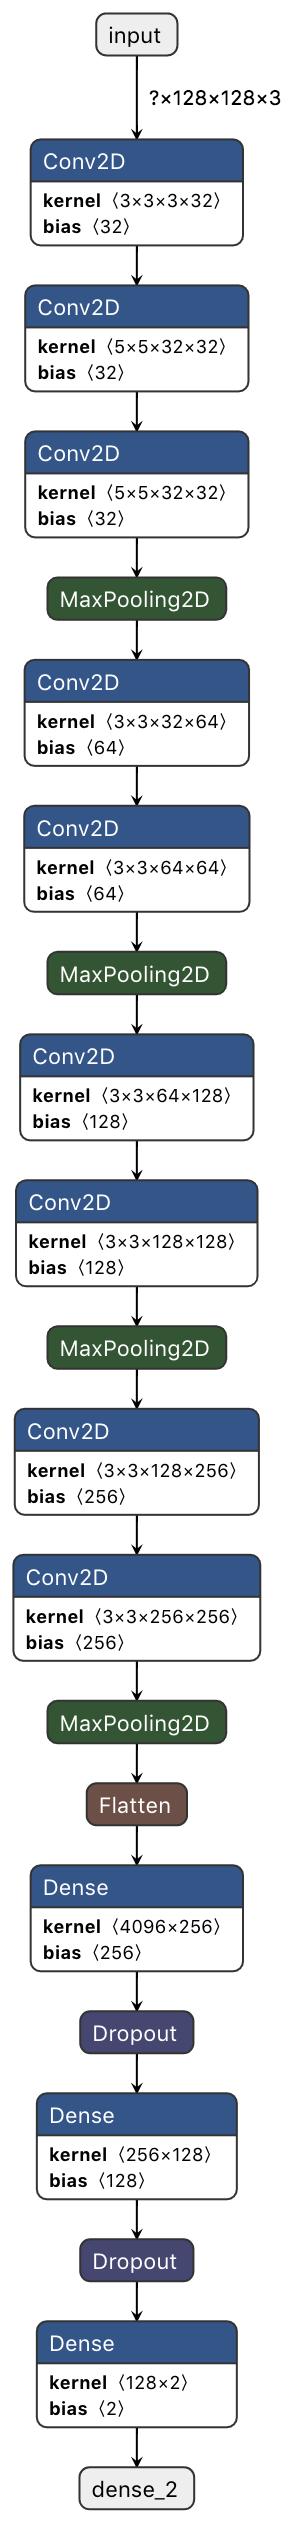

In [7]:
# 建立模型（深度学习：卷积神经网络CNN）

# 在Keras中有两种深度学习的模型：序列模型（Sequential）和通用模型（Model）
# 这里我们采用序列模型（Sequential），层的堆叠，也可以说逐层的添加网络结构
model = tf.keras.Sequential()

# 添加输入层
# filters卷积核数目(即输出的维度),kernel_size大小为3×3过的过滤器/卷积核，activation激活函数
# padding填白，由于每次卷积图像都会缩小，这样卷积不了几次。我们可以采用padding的方法，我们每次卷积前，先给图片周围都补一圈空白，让卷积之后图片跟原来一样大
# 1>padding="same",在每次卷积前，先给图片周围都补一圈空白，让卷积之后的图片大小不变，这样的padding方式称为 “Same”方式
# 2>padding="valid",在每次卷积前,不经过任何的填白，图像会随着卷积而不断缩小，这样的padding方式称为 “Valid”方式
# input_shape，当作为模型的第一层时,需要指出输入的形状，即?x128x128x3 ,第一维自动根据batch_size指定
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),padding="same",activation="relu",input_shape=(width,height,channels)))

# 添加卷积层 Convolutional layer
# kernel 3x3x3x32 (第一个"3x3"指的是卷积核的尺寸大小为3x3，第二个"x3"指的是输入层的输出维度为3，第三个"x32"指的是积核数目，即这一层卷积输出的维度为32)
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=(3, 3),activation="relu"))
# 添加卷积层 Convolutional layer
# kernel 5x5x32x32 (第一个"5x5"指的是卷积核的尺寸大小为5x5，第二个"x32"指的是上一层卷积的输出维度为32，第三个"x32"指的是积核数目，即这一层卷积输出的维度为32)
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=(5, 5),activation="relu"))
# 添加池化层 Pooling layer
# 池化层，是为了提取一定区域的主要特征，并减少参数数量，防止模型过拟合。（主要包含两类Maxpooling和Averagepooling）
# pool_size配置池化窗口的维度，包括长和宽。
# 这里指的是采用Maxpooling,在2x2的池化窗口选取这个区域的最大值，pooling之后，输入的长宽都会缩小2倍，channels不变。
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

# 添加卷积层 Convolutional layer
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu"))
# 添加卷积层 Convolutional layer
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu"))
# 添加池化层 Pooling layer
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

# 添加卷积层 Convolutional layer
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation="relu"))
# 添加卷积层 Convolutional layer
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation="relu"))
# 添加池化层 Pooling layer
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

# 添加卷积层 Convolutional layer
model.add(tf.keras.layers.Conv2D(256, (3, 3), activation="relu"))
# 添加卷积层 Convolutional layer
model.add(tf.keras.layers.Conv2D(256, (3, 3), activation="relu"))
# 添加池化层 Pooling layer
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

# 将二维数据拉直
# 简单的讲，就是讲二维数据按行拉直，转换为一维数据，为后面添加全连接层 Fully Connected layer做准备
# array([[1,2],[3,4],[5,6]]) --> array([1, 2, 3, 4, 5, 6])
model.add(tf.keras.layers.Flatten())

# 添加全连接层 Fully Connected layer
# 全连接层，就是我们人工神经网络中的那种最普通的层，就是一排神经元
# 256指的是这一层输出空间的维度，activation指的是激活函数
model.add(tf.keras.layers.Dense(256, activation="relu"))
# 添加Dropout层
# 防止过拟合，也就是说为了预防模型在训练集上表现的很好，但对未知样本的预测表现一般，泛化能力较差的情况发生
# 在Dropout层随机丢弃50%的神经元，如果我们模型训练的很好的话，是不会影响最后的准确性的
model.add(tf.keras.layers.Dropout(0.5))

# 添加全连接层 Fully Connected layer
model.add(tf.keras.layers.Dense(128, activation="relu"))
# 添加Dropout层
model.add(tf.keras.layers.Dropout(0.5))

# 添加输出层
# 我们最后只需要LYMPHOCYTE-淋巴细胞和NEUTROPHIL-中性粒细胞这两个分类结果，因此输出层只需要输出维度为2
# activation激活函数为"softmax"也可以间接表明，这一层是输出层
model.add(tf.keras.layers.Dense(2, activation='softmax'))


**训练模型（由于训练量比较大，这个阶段大概持续一个小时左右）**

In [8]:
# 训练模型

# 1.设置训练前的参数
# loss损失函数参数，这里指的是交叉熵损失函数
# optimizer优化器参数，梯度下降最常见的三种变形 bgd，sgd，adam（adam是实际学习中最常用的算法）
# 在训练和测试期间，模型要评估的度量标准列表，通常将使用metrics=['accuracy']
model.compile(loss=tf.keras.losses.CategoricalCrossentropy(), optimizer='adam', metrics=["accuracy"])

# 2.开始训练
# batch_size每次梯度更新的样本数，epochs训练模型的迭代数/总轮数，validation_split将训练数据的一部分用作验证数据
# verbose日志显示，0为不在标准输出流输出日志信息，1为输出进度条记录，2为每个epoch输出一行记录
# shuffle=True,指的是在每个epoch之前对训练数据进行洗牌
model.fit(X_all, y_all, batch_size=64, epochs=20, validation_split=0.2, verbose=1, shuffle=True)

Epoch 1/20
63/63 [==============================] - 171s 3s/step - loss: 0.6742 - accuracy: 0.6186 - val_loss: 0.7991 - val_accuracy: 0.0000e+00
Epoch 2/20
63/63 [==============================] - 168s 3s/step - loss: 0.5716 - accuracy: 0.6575 - val_loss: 0.9904 - val_accuracy: 0.4092
Epoch 3/20
63/63 [==============================] - 169s 3s/step - loss: 0.2718 - accuracy: 0.9059 - val_loss: 0.4259 - val_accuracy: 0.9649
Epoch 4/20
63/63 [==============================] - 166s 3s/step - loss: 0.1232 - accuracy: 0.9553 - val_loss: 0.2961 - val_accuracy: 0.9338
Epoch 5/20
63/63 [==============================] - 167s 3s/step - loss: 0.0956 - accuracy: 0.9726 - val_loss: 0.0245 - val_accuracy: 0.9930
Epoch 6/20
63/63 [==============================] - 167s 3s/step - loss: 0.0435 - accuracy: 0.9844 - val_loss: 0.1443 - val_accuracy: 0.9689
Epoch 7/20
63/63 [==============================] - 166s 3s/step - loss: 0.1184 - accuracy: 0.9779 - val_loss: 0.0770 - val_accuracy: 0.9789
Epoch 8/2

**预测结果**

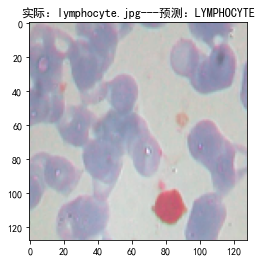

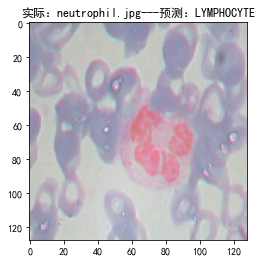

In [12]:
"""
用来验证模型
"""

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf


# 类别列表
blood_class = ["LYMPHOCYTE", "NEUTROPHIL"]
# 输入宽度
width = 128
# 输入高度
height = 128

# 读取测试集的图片
def read_image(test_data,src):
    # opencv库,根据路径读取图片
    im = cv2.imread(test_data+"/"+src)
    # 根据输出尺寸resize图片尺寸
    im = cv2.resize(im, (width, height))
    return im

# 标准化数据集
# np.mean()，对矩阵所有元素求均值
# np.std()，计算矩阵标准差
def center_normalize(x):
    return (x - np.mean(x)) / np.std(x)

# 验证模型
def evaluate_mode(test_data):
    """

    :param test_data: 测试集文件的路径
    :param save_model_path: 最终权重文件路径
    :return:
    """
    # 根据测试集文件的路径，遍历测试集的图片
    # listdir()方法，获取当前文件夹中所有的子文件(返回一个列表):
    for im in os.listdir(test_data):
        # 调用，读取测试集的图片
        img = read_image(test_data,im)
        # 对测试图片数据img,进行标准化处理
        img_norm = center_normalize(img)

        # 预测结果
        # 在二维数据的情况下，axis=1代表扩展行，axis=0代表扩展列
        # 使用predict()方法进行预测时，返回值是数值，表示样本属于每一个类别的概率
        # numpy.argmax()方法找到样本以最大概率所属的类别作为样本的预测标签(返回axis轴方向最大值的索引)
        predict = np.argmax(model.predict(np.expand_dims(np.array(img_norm), axis=0)))

        # ===================画图=======================
        # 设置rc参数显示中文标题，设置字体为SimHei显示中文
        plt.rcParams['font.sans-serif'] = 'SimHei'
        plt.rcParams['axes.unicode_minus'] = False
        # plt.figure(),方便连续跑多张图片
        plt.figure()
        plt.imshow(img)
        title = "实际：{0}---预测：{1}".format(im,blood_class[predict])
        plt.title(title)
        plt.show()

if __name__ == '__main__':
    # 调用预测方法
    evaluate_mode("Pictures")